# Лабораторная работа
## Анализ и визуализация данных об успеваемости студентов

Студент (ФИО + ИСУ): Ашихмин Кирилл, ИСУ 504639
Группа: P3124
Дата: 16.09.2026

---

### Что нужно сделать
Заполните этот notebook по шагам:
1. загрузите датасет;
2. выполните первичный анализ;
3. обработайте данные;
4. создайте новые признаки;
5. выполните группировку и агрегацию;
6. постройте графики;
7. сделайте выводы.

## 1. Импорт библиотек

Импортируйте библиотеки, которые понадобятся в работе.

Минимально ожидается использование:
- `pandas`
- `matplotlib.pyplot`

При необходимости можно добавить и другие библиотеки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Графики рисуются прямо в ноутбуке и сохраняются в его вывод.
# Иначе собранный в CI HTML-отчёт останется без картинок.
%matplotlib inline

# Единый стиль для всех графиков работы.
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

print('pandas:', pd.__version__)

pandas: 3.0.5


## 2. Загрузка данных

Считайте CSV-файл в `DataFrame`.

Ожидается, что датасет лежит по относительному пути:
`data/StudentsPerformance.csv`

После загрузки данных выведите:
- первые 5 строк;
- размер таблицы.

In [2]:
data = pd.read_csv('data/StudentsPerformance.csv')

print('Размер таблицы:', data.shape)
data.head()

Размер таблицы: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Первичный просмотр структуры данных

На этом этапе нужно посмотреть:
- названия столбцов;
- типы данных;
- базовую информацию о таблице.

Подумайте:
- какие признаки числовые;
- какие признаки категориальные.

In [3]:
print('Названия столбцов:')
for column in data.columns:
    print(' -', column)

print('\nТипы данных и заполненность:')
data.info()

Названия столбцов:
 - gender
 - race/ethnicity
 - parental level of education
 - lunch
 - test preparation course
 - math score
 - reading score
 - writing score

Типы данных и заполненность:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 4. Проверка пропущенных значений

Проверьте, есть ли в таблице пустые значения.

Кратко прокомментируйте результат:
- есть ли пропуски;
- в каких столбцах они находятся;
- требуется ли обработка.

In [4]:
# isnull() даёт таблицу True/False, sum() складывает True как единицы.
missing = data.isnull().sum()

print('Пропусков по столбцам:')
print(missing.to_string())
print('\nВсего пропусков:', missing.sum())
print('Полных дубликатов строк:', data.duplicated().sum())

Пропусков по столбцам:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0

Всего пропусков: 0
Полных дубликатов строк: 0


### Краткий комментарий
Напишите 1–3 предложения о результате проверки пропусков.

### Краткий комментарий

Пропусков в данных нет — все 1000 строк заполнены по всем восьми столбцам,
полных дубликатов тоже нет. Дополнительная обработка пропусков не требуется,
можно сразу переходить к преобразованию данных.

Это редкий случай: датасет учебный и заранее вычищен. В реальных данных
(например, в лабораторной работе по Titanic) пропуски занимают до 77% столбца.

## 5. Переименование столбцов

Приведите названия столбцов к более удобному виду.

Рекомендуется:
- убрать пробелы;
- заменить специальные символы;
- использовать короткие и понятные имена.

Пример подхода:
- `math score` → `math_score`
- `test preparation course` → `test_prep`

После переименования снова выведите список столбцов.

In [5]:
# Приводим названия к единому виду: без пробелов и специальных символов,
# короткие и понятные.
data = data.rename(columns={
    'race/ethnicity': 'race',
    'parental level of education': 'parent_education',
    'test preparation course': 'test_prep',
    'math score': 'math_score',
    'reading score': 'reading_score',
    'writing score': 'writing_score',
})

print('Обновлённый список столбцов:')
print(list(data.columns))

Обновлённый список столбцов:
['gender', 'race', 'parent_education', 'lunch', 'test_prep', 'math_score', 'reading_score', 'writing_score']


## 6. Создание новых признаков

На этом этапе нужно самостоятельно создать **не менее одного нового признака** на основе существующих столбцов.

Обязательный вариант:
- `average_score` — средний балл по трем предметам.

Можно добавить и другие признаки, если считаете это полезным.

In [6]:
# 1. Средний балл по трём предметам — обязательный признак.
data['average_score'] = data[['math_score', 'reading_score', 'writing_score']].mean(axis=1).round(2)

# 2. Разрыв между лучшим и худшим предметом: показывает, насколько студент
#    "равномерный" — силён во всём или только в чём-то одном.
data['score_range'] = (data[['math_score', 'reading_score', 'writing_score']].max(axis=1)
                       - data[['math_score', 'reading_score', 'writing_score']].min(axis=1))

# 3. Категория успеваемости по среднему баллу.
data['grade'] = pd.cut(
    data['average_score'],
    bins=[0, 60, 70, 80, 100],
    labels=['низкий', 'средний', 'хороший', 'высокий'],
)

data[['math_score', 'reading_score', 'writing_score',
      'average_score', 'score_range', 'grade']].head()

,math_score,reading_score,writing_score,average_score,score_range,grade
0,72,72,74,72.67,2,хороший
1,69,90,88,82.33,21,высокий
2,90,95,93,92.67,5,высокий
3,47,57,44,49.33,13,низкий
4,76,78,75,76.33,3,хороший


## 7. Описательная статистика

Постройте базовую статистику по числовым признакам.

Подумайте:
- какие значения являются типичными;
- есть ли большой разброс;
- какие признаки удобно анализировать дальше.

In [7]:
data[['math_score', 'reading_score', 'writing_score',
      'average_score', 'score_range']].describe().round(2)

,math_score,reading_score,writing_score,average_score,score_range
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05,67.77,9.79
std,15.16,14.60,15.20,14.26,5.29
min,0.00,17.00,10.00,9.00,0.00
25%,57.00,59.00,57.75,58.33,6.00
50%,66.00,70.00,69.00,68.33,9.00
75%,77.00,79.00,79.00,77.67,13.00
max,100.00,100.00,100.00,100.00,28.00


### Краткий комментарий
Напишите 2–4 предложения по результатам описательной статистики.

### Краткий комментарий

Типичные значения. Средние баллы по трём предметам близки: математика
66.09, чтение 69.17, письмо 68.05. Медианы почти совпадают со средними
(66, 70, 69), то есть распределения примерно симметричны, без сильного перекоса.

Разброс. Стандартное отклонение около 15 баллов у всех трёх предметов —
разброс заметный, но одинаковый по предметам.

Крайние значения. Минимум по математике равен **0, тогда как по чтению
17, а по письму 10. Ноль встречается ровно у одного студента. Это не ошибка
данных: у того же студента низкие баллы и по остальным предметам (17 и 10),
то есть результат согласованный.

Новый признак `score_range` (разрыв между лучшим и худшим предметом)
в среднем равен 9.79** балла, медиана — 9. То есть у типичного студента
предметы расходятся примерно на 10 баллов: большинство показывают близкий
уровень по всем трём предметам, резких перекосов в сторону одного предмета
почти нет. Максимальный разрыв — 28 баллов.

## 8. Выделение числовых и категориальных признаков

Сформируйте отдельно:
- список числовых признаков;
- список категориальных признаков.

In [8]:
# Числовые признаки — те, по которым имеет смысл считать среднее.
numeric_features = data.select_dtypes(include='number').columns.tolist()

# Категориальные — текстовые метки, по которым можно группировать.
categorical_features = data.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print('Числовые признаки:', numeric_features)
print('Категориальные признаки:', categorical_features)

Числовые признаки: ['math_score', 'reading_score', 'writing_score', 'average_score', 'score_range']
Категориальные признаки: ['gender', 'race', 'parent_education', 'lunch', 'test_prep', 'grade']


## 9. Группировка и агрегация

Выполните группировку данных и вычислите агрегированные показатели.

Минимально нужно посчитать:
- средний балл по `test_prep`;
- средний балл по `gender`;
- средний балл по `parent_education`.

При необходимости можно добавить дополнительные группировки.

In [9]:
for column in ['test_prep', 'gender', 'parent_education', 'lunch']:
    print(f'--- средний балл по {column} ---')
    grouped = (data.groupby(column, observed=True)['average_score']
               .agg(['mean', 'count'])
               .round(2)
               .sort_values('mean', ascending=False))
    print(grouped.to_string())
    print()

--- средний балл по test_prep ---
            mean  count
test_prep              
completed  72.67    358
none       65.04    642

--- средний балл по gender ---
         mean  count
gender              
female  69.57    518
male    65.84    482

--- средний балл по parent_education ---
                     mean  count
parent_education                
master's degree     73.60     59
bachelor's degree   71.92    118
associate's degree  69.57    222
some college        68.48    226
some high school    65.11    179
high school         63.10    196

--- средний балл по lunch ---
               mean  count
lunch                     
standard      70.84    645
free/reduced  62.20    355



### Краткий комментарий
Опишите, какие различия между группами удалось заметить.

### Краткий комментарий

Различия между группами заметные и устойчивые:

| Признак | Разница в среднем балле |
|---|---|
| `lunch` (стандартный обед против льготного) | +8.6 балла |
| `test_prep` (курс пройден против не пройден) | +7.6 балла |
| `parent_education` (магистр против школы) | +10.5 балла |
| `gender` (девушки против юношей) | +3.7 балла |

Самый сильный фактор — тип обеда: 70.84 против 62.20. Сам по себе обед,
разумеется, ни на что не влияет — это косвенный показатель дохода семьи
(льготное питание получают студенты из малообеспеченных семей). То есть
признак отражает социально-экономическое положение, а не питание.

То же относится к образованию родителей: от 73.60 у детей магистров до 63.10
у детей со школьным образованием родителей.

Подготовительный курс — единственный фактор из перечисленных, на который
студент действительно может повлиять.

## 10. Визуализация 1 — гистограмма

Постройте гистограмму для одного из числовых признаков.

Обязательный вариант:
- `math_score`

Не забудьте:
- заголовок;
- подпись оси X;
- подпись оси Y;
- сетку при необходимости.

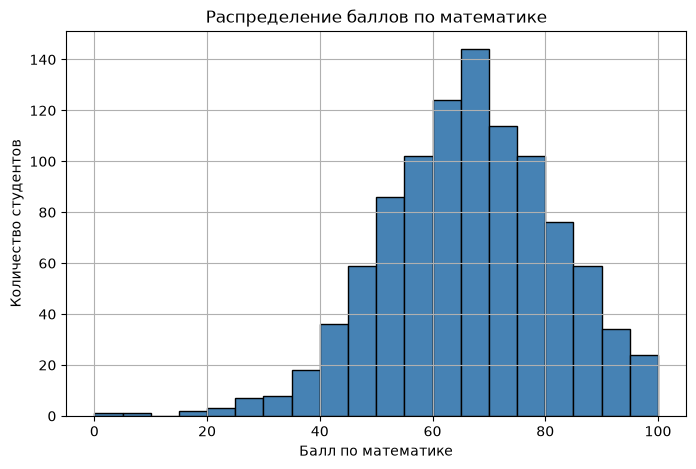

In [10]:
plt.figure()
plt.hist(data['math_score'], bins=20, color='steelblue', edgecolor='black')

plt.title('Распределение баллов по математике')
plt.xlabel('Балл по математике')
plt.ylabel('Количество студентов')

plt.show()

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

Распределение баллов по математике близко к нормальному: пик приходится на
65-70 баллов, а количество студентов плавно убывает в обе стороны.

Слева виден длинный «хвост» — несколько студентов с очень низкими баллами
(вплоть до 0), тогда как справа распределение упирается в естественный
потолок в 100 баллов. Из-за этого левый хвост длиннее правого.

## 11. Визуализация 2 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `test_prep`.

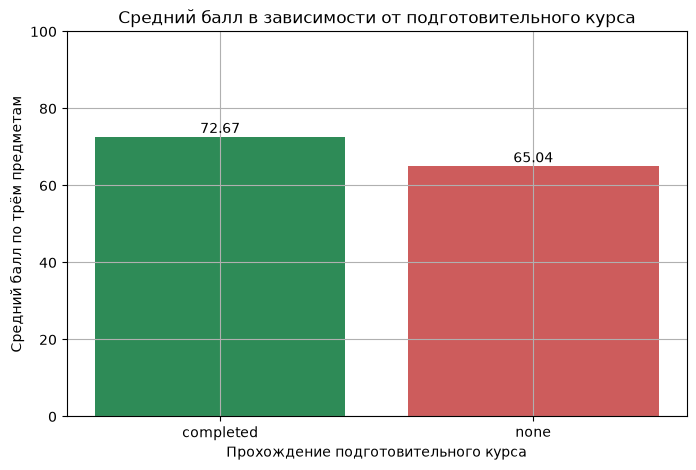

In [11]:
mean_by_prep = data.groupby('test_prep')['average_score'].mean().round(2)

plt.figure()
bars = plt.bar(mean_by_prep.index, mean_by_prep.values, color=['seagreen', 'indianred'])

plt.title('Средний балл в зависимости от подготовительного курса')
plt.xlabel('Прохождение подготовительного курса')
plt.ylabel('Средний балл по трём предметам')
plt.ylim(0, 100)

# Подписываем значения прямо на столбцах — так график читается без таблицы.
for bar, value in zip(bars, mean_by_prep.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 1, f'{value}', ha='center')

plt.show()

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

Студенты, прошедшие подготовительный курс, в среднем набирают 72.67 балла
против 65.04 у не проходивших — разница 7.6 балла.

Важная оговорка: это корреляция, а не доказательство эффективности курса.
Курс не назначался случайным образом — студенты записывались на него сами.
Возможно, записываются именно более мотивированные, и они набрали бы больше
и без курса. Чтобы измерить эффект курса, нужен эксперимент со случайным
распределением участников.

## 12. Визуализация 3 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `gender`.

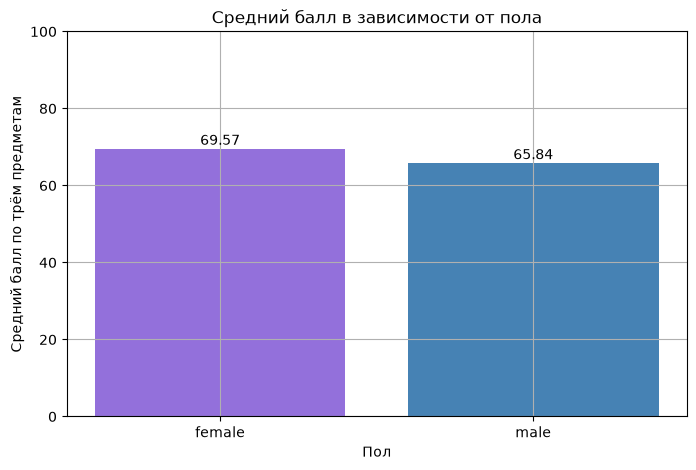

In [12]:
mean_by_gender = data.groupby('gender')['average_score'].mean().round(2)

plt.figure()
bars = plt.bar(mean_by_gender.index, mean_by_gender.values, color=['mediumpurple', 'steelblue'])

plt.title('Средний балл в зависимости от пола')
plt.xlabel('Пол')
plt.ylabel('Средний балл по трём предметам')
plt.ylim(0, 100)

for bar, value in zip(bars, mean_by_gender.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 1, f'{value}', ha='center')

plt.show()

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

По среднему баллу девушки опережают юношей: 69.57 против 65.84,
разница 3.7 балла.

Но это самая маленькая разница из всех рассмотренных факторов — заметно
меньше, чем эффект от типа обеда (8.6) или образования родителей (10.5).
И, как показано в следующем разделе, усреднённый балл скрывает куда более
интересную картину.

## 13. Визуализация 4 — диаграмма рассеяния

Постройте диаграмму рассеяния для зависимости между двумя числовыми признаками.

Обязательный вариант:
- `math_score` и `reading_score`

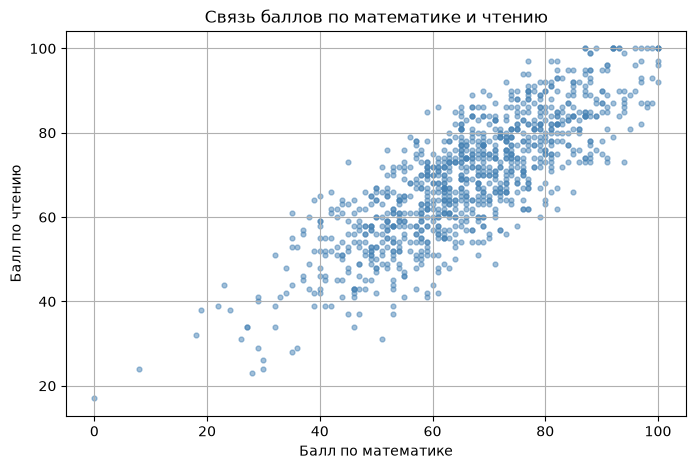

Коэффициент корреляции: 0.818


In [13]:
plt.figure()
plt.scatter(data['math_score'], data['reading_score'], s=12, alpha=0.5, color='steelblue')

plt.title('Связь баллов по математике и чтению')
plt.xlabel('Балл по математике')
plt.ylabel('Балл по чтению')

plt.show()

correlation = data['math_score'].corr(data['reading_score'])
print(f'Коэффициент корреляции: {correlation:.3f}')

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

Точки вытянуты вдоль диагонали: студенты с высоким баллом по математике, как
правило, хорошо справляются и с чтением. Коэффициент корреляции 0.818 —
это сильная положительная связь.

Практический смысл: предметные результаты не независимы, а отражают общий
уровень подготовки студента. Связь между чтением
и письмом ещё сильнее — 0.955, то есть эти два навыка почти взаимозаменяемы
как показатели.

## 14. Дополнительная визуализация

Добавьте **еще один график самостоятельно**.

Можно выбрать один из вариантов:
- график по `parent_education`;
- график по `lunch`;
- boxplot;
- еще одна гистограмма;
- другой осмысленный вариант.

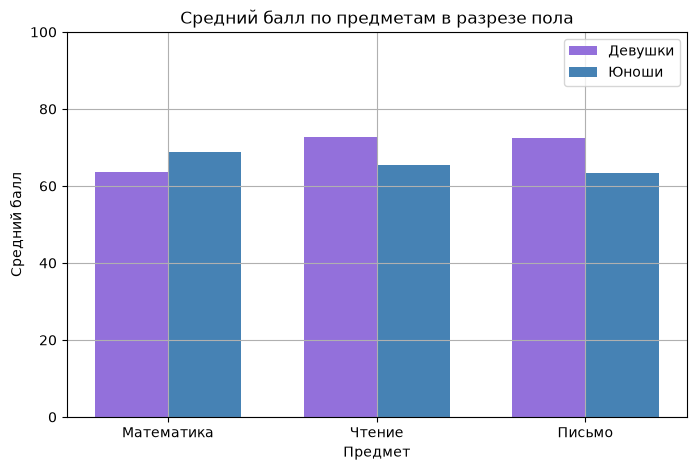

        math_score  reading_score  writing_score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31


In [14]:
# Самостоятельная часть: средний балл по каждому предмету в разрезе пола.
# Одна усреднённая оценка скрывает различия между предметами — посмотрим их
# по отдельности.
subjects = ['math_score', 'reading_score', 'writing_score']
subject_labels = ['Математика', 'Чтение', 'Письмо']

mean_by_subject = data.groupby('gender')[subjects].mean().round(2)

positions = range(len(subjects))
bar_width = 0.35

plt.figure()
plt.bar([p - bar_width / 2 for p in positions], mean_by_subject.loc['female'],
        width=bar_width, label='Девушки', color='mediumpurple')
plt.bar([p + bar_width / 2 for p in positions], mean_by_subject.loc['male'],
        width=bar_width, label='Юноши', color='steelblue')

plt.title('Средний балл по предметам в разрезе пола')
plt.xlabel('Предмет')
plt.ylabel('Средний балл')
plt.xticks(list(positions), subject_labels)
plt.ylim(0, 100)
plt.legend()

plt.show()

print(mean_by_subject.to_string())

### Вывод по графику
Напишите 1–3 предложения.

### Вывод по графику

Здесь видно то, что скрывал усреднённый балл: преимущество по полу
переворачивается в зависимости от предмета.

| Предмет | Девушки | Юноши | Разница |
|---|---|---|---|
| Математика | 63.63 | 68.73 | -5.1 в пользу юношей |
| Чтение | 72.61 | 65.47 | +7.1 в пользу девушек |
| Письмо | 72.47 | 63.31 | +9.2 в пользу девушек |

Юноши сильнее в математике, девушки — в чтении и письме, причём разрывы
по отдельным предметам (5-9 баллов) вдвое больше, чем итоговая разница по
среднему баллу (3.7).

Методический вывод: усреднение по нескольким показателям может полностью
замаскировать противоположно направленные различия. Прежде чем делать вывод
по агрегированной величине, стоит посмотреть на её составляющие.

---

В финале кратко ответим: что было сделано, какие библиотеки и методы
использованы, какие закономерности удалось заметить и какие трудности
возникли в процессе выполнения.


## 15. Итоговый вывод

1. Что было сделано в работе.
Загружен и проанализирован датасет успеваемости 1000 студентов
(StudentsPerformance, Kaggle). Выполнен первичный анализ, проверка пропусков,
переименование столбцов, создание трёх новых признаков, описательная
статистика, группировка по четырём категориальным признакам и построение пяти
графиков с выводами по каждому.

2. Использованные библиотеки и методы.

| Инструмент | Что использовалось |
|---|---|
| `pandas` | `read_csv`, `info`, `isnull`, `duplicated`, `rename`, `describe`, `groupby`, `agg`, `pd.cut`, `select_dtypes`, `corr` |
| `matplotlib` | `hist`, `bar`, `scatter`, группированная столбчатая диаграмма, подписи осей и значений |

3. Замеченные закономерности.

* Данные полные: 1000 строк, ни одного пропуска, ни одного дубликата.
* Самый сильный фактор успеваемости — тип обеда (разница 8.6 балла) и
  образование родителей (10.5 балла). Оба признака косвенно отражают
  социально-экономическое положение семьи, а не что-то связанное с учёбой
  напрямую.
* Подготовительный курс даёт +7.6 балла, но это корреляция: на курс
  записывались добровольно, поэтому эффект может объясняться мотивацией.
* Предметные баллы сильно связаны между собой: математика и чтение — 0.818,
  чтение и письмо — 0.955.
* Различие по полу переворачивается в зависимости от
  предмета. Юноши лучше в математике (+5.1), девушки — в чтении (+7.1) и
  письме (+9.2). По среднему баллу разница составляет лишь 3.7 балла, то есть
  усреднение скрывает противоположно направленные эффекты.

4. Трудности в процессе выполнения.

* Признак с нулевым баллом. Минимум по математике равен 0, и первым делом
  это выглядит как ошибка данных. Пришлось проверить строку целиком: у того же
  студента 17 и 10 баллов по другим предметам, то есть результат согласованный
  и удалять его нельзя.
* Выбор бэкенда matplotlib для CI. В работе с NumPy графики сохранялись в
  файл через бэкенд `Agg`. Здесь так делать нельзя: при `Agg` картинки не
  попадают в вывод ячейки, и HTML-отчёт, который собирает CI, окажется без
  графиков. Нужен именно `%matplotlib inline`, который работает и без
  графического окружения.
* Интерпретация различий между группами. Самым сложным оказалось не
  посчитать разницу, а корректно её объяснить: связь типа обеда с баллами
  легко принять за причинную, хотя обед — лишь индикатор дохода семьи.

## 16. Проверка перед сдачей

Перед отправкой убедитесь, что:
- все ячейки выполняются без ошибок;
- код написан последовательно и понятно;
- новые признаки действительно созданы вами;
- столбцы переименованы;
- построено не менее 4 обязательных графиков;
- под каждым графиком есть вывод;
- notebook сохранен после выполнения `Restart & Run All`.